# Classification of Blogs

In [1]:
!pip install mlflow

In [2]:
!pip install pyngrok

In [3]:
!pip install seaborn 
!pip install nltk

In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier, LogisticRegression

import mlflow
import mlflow.sklearn

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adithyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
train_df=pd.read_csv("./dataset/test.csv",header=0,names=['classid','title','desc'])
test_df=pd.read_csv("dataset/test.csv",header=0,names=['classid','title','desc'])


In [6]:
train_df.head()

,classid,title,desc
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [7]:
test_df.head()

,classid,title,desc
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [8]:
train_df['text'] = train_df['title'] + " " + train_df['desc']
test_df['text'] = test_df['title'] + " " + test_df['desc']

In [9]:
train_x = train_df['text']
train_y = train_df['classid']

test_x = test_df['text']
test_y = test_df['classid']

In [10]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()

    # remove special characters
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [11]:
train_x = train_x.apply(preprocess)
test_x = test_x.apply(preprocess)

print(train_x.head())  # MUST look like normal words

0    fears n pension talks unions representing work...
1    race second private team sets launch date huma...
2    ky company wins grant study peptides ap ap com...
3    prediction unit helps forecast wildfires ap ap...
4    calif aims limit farmrelated smog ap ap southe...
Name: text, dtype: object


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)  # limit features (better performance)

train_vec = tfidf.fit_transform(train_x)
test_vec = tfidf.transform(test_x)

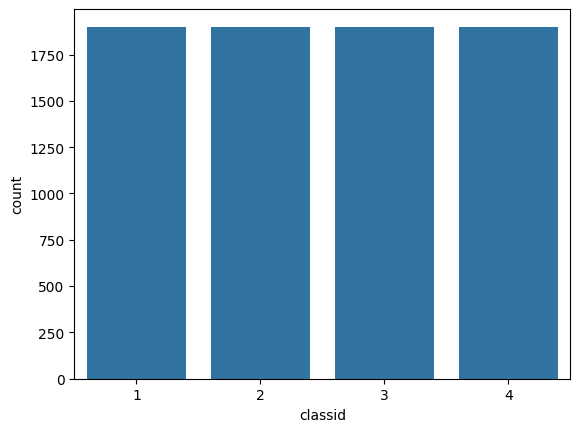

In [13]:
sns.countplot(x=train_y)
plt.show()

In [14]:
tfidf = TfidfVectorizer(min_df=3)

train_vec = tfidf.fit_transform(train_x)
test_vec = tfidf.transform(test_x)

print("Features:", len(tfidf.get_feature_names_out()))

Features: 8556


In [15]:
import mlflow
import mlflow.sklearn

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import LinearSVC

# -------------------------------
# MLflow Setup
# -------------------------------
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("News Classification Advanced")

# -------------------------------
# Tuned Models
# -------------------------------
models = {
    "Naive_Bayes": MultinomialNB(alpha=0.5),
    "SGD": SGDClassifier(alpha=0.0001, max_iter=1000),
    "Logistic_Regression": LogisticRegression(max_iter=1000, C=1.0),
    "SVM": LinearSVC(C=1.0)
}

best_model = None
best_score = 0
best_name = ""

# -------------------------------
# Training Loop
# -------------------------------
for name, model in models.items():

    with mlflow.start_run(run_name=name):

        # Train
        model.fit(train_vec, train_y)

        # Predict
        pred = model.predict(test_vec)

        # Metrics
        acc = accuracy_score(test_y, pred)
        precision = precision_score(test_y, pred, average='weighted')
        recall = recall_score(test_y, pred, average='weighted')
        f1 = f1_score(test_y, pred, average='weighted')

        # Log params
        mlflow.log_param("model", name)

        # Log metrics
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)

        # Log model
        mlflow.sklearn.log_model(model, name="model")

        print(f"{name} → Accuracy: {acc:.4f}")

        # Track best model
        if acc > best_score:
            best_score = acc
            best_model = model
            best_name = name

# -------------------------------
# Log Best Model Separately
# -------------------------------
with mlflow.start_run(run_name="BEST_MODEL"):

    mlflow.log_param("best_model", best_name)
    mlflow.log_metric("best_accuracy", best_score)

    mlflow.sklearn.log_model(best_model, name="best_model")

print("\n🔥 BEST MODEL:", best_name)
print("🔥 BEST ACCURACY:", best_score)

/opt/anaconda3/envs/gpt-notebook/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/19 21:16:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/19 21:16:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising 

Naive_Bayes → Accuracy: 0.9314
SGD → Accuracy: 0.9683


2026/04/19 21:16:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/19 21:16:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic_Regression → Accuracy: 0.9495


2026/04/19 21:16:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SVM → Accuracy: 0.9892

🔥 BEST MODEL: SVM
🔥 BEST ACCURACY: 0.9892105263157894


In [16]:
!mlflow ui \
--host 127.0.0.1 \
--port 5001 \
--allowed-hosts '*' \
--cors-allowed-origins '*'

Backend store URI not provided. Using ./mlruns
Registry store URI not provided. Using backend store URI.
/opt/anaconda3/envs/gpt-notebook/lib/python3.10/site-packages/mlflow/server/handlers.py:377: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, artifact_uri)
/opt/anaconda3/envs/gpt-notebook/lib/python3.10/site-packages/mlflow/server/handlers.py:412: FutureWarning: The filesystem model registry backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStor

In [17]:
import joblib

# Save without overwriting existing files
joblib.dump(tfidf, "tfidf_saved.pkl")
joblib.dump(best_model, "best_model_saved.pkl")

print("✅ Vectorizer and Best Model saved successfully!")

✅ Vectorizer and Best Model saved successfully!
